# Notebook 2 — Cleaning, Merging, Feature Engineering & EDA
### Project: Retail Sales & Customer Purchase Prediction (Group A)

This notebook:
1. Loads the two raw sheets and **merges them into one dataset** (schema was verified identical in Notebook 1)
2. Cleans the data with **documented, non-destructive rules** — nothing is silently deleted
3. Creates derived business variables (`TotalAmount`, date parts, customer-level features)
4. Answers 12 business questions using Pandas/NumPy
5. Produces 8+ Matplotlib visualizations with interpretation
6. Saves the cleaned dataset to `data/cleaned/`, separate from the untouched raw file


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

RAW_PATH = "../data/raw/online_retail_II.xlsx"
CHART_DIR = "../outputs/charts"
CLEAN_DIR = "../data/cleaned"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR, exist_ok=True)

## 1. Load and Merge the Two Sheets

In [2]:
sheet_1 = pd.read_excel(RAW_PATH, sheet_name="Year 2009-2010")
sheet_2 = pd.read_excel(RAW_PATH, sheet_name="Year 2010-2011")

# Schema was confirmed identical in Notebook 1, so a simple concat is a valid merge
df = pd.concat([sheet_1, sheet_2], ignore_index=True)
print("Merged shape:", df.shape)
print("Merged date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())
df.head()

Merged shape: (1067371, 8)
Merged date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Before-Cleaning Snapshot
Recorded here so we can show a clear before/after comparison.

In [3]:
before_rows = len(df)
before_missing = df.isnull().sum().sum()
before_duplicates = df.duplicated().sum()
before_cancel = df['Invoice'].astype(str).str.startswith('C').sum()

print("BEFORE CLEANING")
print("Rows:", before_rows)
print("Total missing cells:", before_missing)
print("Duplicate rows:", before_duplicates)
print("Cancelled-invoice rows:", before_cancel)

BEFORE CLEANING
Rows: 1067371
Total missing cells: 247389
Duplicate rows: 34335
Cancelled-invoice rows: 19494


## 3. Cleaning Decisions (documented, one rule at a time)

| # | Issue | Rule applied | Reason |
|---|---|---|---|
| 1 | Full-row duplicates | Drop | Same invoice/product/qty/price/date/customer repeated — genuine duplicate scan/entry, not two separate purchases |
| 2 | Cancelled invoices (`Invoice` starts with `C`) | Keep in cleaned file, flagged `IsCancelled=True`, **excluded from revenue/customer/ML analysis** | These represent returns, not completed sales; deleting them would hide return behaviour, so we flag instead of erasing |
| 3 | Adjustment invoices (`Invoice` starts with `A`, e.g. "Adjust bad debt") | Flag `IsAdjustment=True`, exclude from sales analysis | Accounting entries, not customer purchases |
| 4 | Non-product `StockCode`s (POST, DOT, M, BANK CHARGES, AMAZONFEE, PADS, CRUK, C2, D) | Flag `IsAdminCode=True`, exclude from product/revenue analysis | Postage, fees and manual entries are not products and would distort "top product" results |
| 5 | Quantity ≤ 0 outside cancellations (damages, lost, data-entry errors) | Flag `IsInvalidQty=True`, exclude from sales analysis | Not genuine completed sales |
| 6 | Price ≤ 0 | Flag `IsInvalidPrice=True`, exclude from sales analysis | Free items / price errors would understate true order value if included as revenue |
| 7 | Missing `Customer ID` | Keep row (valid for product/revenue-level EDA), **exclude from customer-level and ML analysis** | We cannot attribute the purchase to a specific customer, so customer-level features would be wrong |
| 8 | Missing `Description` | Keep row, fill with `"UNKNOWN"` | Description is not needed for revenue or customer calculations; dropping the row would lose valid Quantity/Price data |

We never delete the raw file. We build one **cleaned dataset** with quality flags, and a **valid-sales
subset** (`df_sales`) used for all revenue, EDA and modeling work below.

In [4]:
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Standardise types
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean['StockCode'] = df_clean['StockCode'].astype(str)

# Quality flags (documented rules above)
df_clean['IsCancelled'] = df_clean['Invoice'].str.startswith('C')
df_clean['IsAdjustment'] = df_clean['Invoice'].str.startswith('A')

special_codes = ['POST', 'DOT', 'M', 'm', 'C2', 'D', 'BANK CHARGES', 'AMAZONFEE', 'PADS', 'CRUK']
df_clean['IsAdminCode'] = df_clean['StockCode'].isin(special_codes)

df_clean['IsInvalidQty'] = df_clean['Quantity'] <= 0
df_clean['IsInvalidPrice'] = df_clean['Price'] <= 0
df_clean['MissingCustomerID'] = df_clean['Customer ID'].isnull()

df_clean['Description'] = df_clean['Description'].fillna('UNKNOWN')

print("Cleaned (flagged) dataset shape:", df_clean.shape)
df_clean.head()

Cleaned (flagged) dataset shape: (1033036, 14)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,IsAdjustment,IsAdminCode,IsInvalidQty,IsInvalidPrice,MissingCustomerID
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,False,False,False,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,False,False,False,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,False,False,False,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,False,False,False,False,False


## 4. Build the Valid-Sales Subset (used for revenue, EDA, customer features)

In [5]:
df_sales = df_clean[
    (~df_clean['IsCancelled']) &
    (~df_clean['IsAdjustment']) &
    (~df_clean['IsAdminCode']) &
    (~df_clean['IsInvalidQty']) &
    (~df_clean['IsInvalidPrice']) &
    (~df_clean['MissingCustomerID'])
].copy()

print("Valid completed-sales rows:", len(df_sales))
print("Unique customers:", df_sales['Customer ID'].nunique())
print("Unique invoices:", df_sales['Invoice'].nunique())
print("Unique products:", df_sales['StockCode'].nunique())

Valid completed-sales rows: 776624
Unique customers: 5861
Unique invoices: 36639


Unique products: 4624


## 5. After-Cleaning Snapshot

In [6]:
after_rows = len(df_clean)
after_duplicates = df_clean.duplicated().sum()
after_valid_sales = len(df_sales)

print("AFTER CLEANING")
print(f"Rows in cleaned+flagged dataset : {after_rows}  (was {before_rows} before dedupe)")
print(f"Duplicate rows remaining        : {after_duplicates}")
print(f"Cancelled rows (flagged)        : {df_clean['IsCancelled'].sum()}")
print(f"Adjustment rows (flagged)       : {df_clean['IsAdjustment'].sum()}")
print(f"Admin/non-product rows (flagged): {df_clean['IsAdminCode'].sum()}")
print(f"Invalid quantity rows (flagged) : {df_clean['IsInvalidQty'].sum()}")
print(f"Invalid price rows (flagged)    : {df_clean['IsInvalidPrice'].sum()}")
print(f"Missing Customer ID (flagged)   : {df_clean['MissingCustomerID'].sum()}")
print(f"\nValid completed-sales rows used for analysis: {after_valid_sales}")
print(f"That is {round(100*after_valid_sales/before_rows,1)}% of the original merged rows.")

AFTER CLEANING
Rows in cleaned+flagged dataset : 1033036  (was 1067371 before dedupe)
Duplicate rows remaining        : 0
Cancelled rows (flagged)        : 19104
Adjustment rows (flagged)       : 6
Admin/non-product rows (flagged): 5524
Invalid quantity rows (flagged) : 22496
Invalid price rows (flagged)    : 6019
Missing Customer ID (flagged)   : 235151

Valid completed-sales rows used for analysis: 776624
That is 72.8% of the original merged rows.


## 6. Derived Business Variables

### Revenue
`TotalAmount = Quantity x Price`

### Date features
Year, Month, MonthName, Day, DayOfWeek, Hour — extracted from `InvoiceDate`.


In [7]:
df_sales['TotalAmount'] = df_sales['Quantity'] * df_sales['Price']

df_sales['Year'] = df_sales['InvoiceDate'].dt.year
df_sales['Month'] = df_sales['InvoiceDate'].dt.month
df_sales['MonthName'] = df_sales['InvoiceDate'].dt.month_name()
df_sales['Day'] = df_sales['InvoiceDate'].dt.day
df_sales['DayOfWeek'] = df_sales['InvoiceDate'].dt.day_name()
df_sales['Hour'] = df_sales['InvoiceDate'].dt.hour

df_sales[['InvoiceDate','Year','Month','MonthName','Day','DayOfWeek','Hour','TotalAmount']].head()

,InvoiceDate,Year,Month,MonthName,Day,DayOfWeek,Hour,TotalAmount
0,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7,83.4
1,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7,81.0
2,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7,81.0
3,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7,100.8
4,2009-12-01 07:45:00,2009,12,December,1,Tuesday,7,30.0


### Customer-Level Features (descriptive, full period)

These describe customers over the *entire* cleaned dataset for EDA purposes. **Note:** this full-period
version is for description only — the leakage-safe version used for Machine Learning in Notebook 3 will be
built from a historical window only, as explained in Notebook 1.

In [8]:
snapshot_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_features = df_sales.groupby('Customer ID').agg(
    TotalSpend=('TotalAmount', 'sum'),
    NumOrders=('Invoice', 'nunique'),
    NumItemsPurchased=('Quantity', 'sum'),
    NumUniqueProducts=('StockCode', 'nunique'),
    LastPurchaseDate=('InvoiceDate', 'max'),
    FirstPurchaseDate=('InvoiceDate', 'min')
).reset_index()

customer_features['AvgOrderValue'] = customer_features['TotalSpend'] / customer_features['NumOrders']
customer_features['Recency'] = (snapshot_date - customer_features['LastPurchaseDate']).dt.days
customer_features['CustomerLifespanDays'] = (customer_features['LastPurchaseDate'] - customer_features['FirstPurchaseDate']).dt.days
customer_features['PurchaseFrequency'] = customer_features['NumOrders'] / customer_features['CustomerLifespanDays'].replace(0, 1)

print("Customer-level feature table shape:", customer_features.shape)
customer_features.head()

Customer-level feature table shape: (5861, 11)


,Customer ID,TotalSpend,NumOrders,NumItemsPurchased,NumUniqueProducts,LastPurchaseDate,FirstPurchaseDate,AvgOrderValue,Recency,CustomerLifespanDays,PurchaseFrequency
0,12346.0,77556.46,12,74285,27,2011-01-18 10:01:00,2009-12-14 08:34:00,6463.038333,326,400,0.030000
1,12347.0,4921.53,8,2967,126,2011-12-07 15:52:00,2010-10-31 14:20:00,615.191250,2,402,0.019900
2,12348.0,1658.40,5,2704,24,2011-09-25 13:13:00,2010-09-27 14:59:00,331.680000,75,362,0.013812
3,12349.0,3678.69,3,1621,137,2011-11-21 09:51:00,2010-04-29 13:20:00,1226.230000,19,570,0.005263
4,12350.0,294.40,1,196,16,2011-02-02 16:01:00,2011-02-02 16:01:00,294.400000,310,0,1.000000


## 7. Pandas & NumPy Demonstration (core operations required by the manual)

In [9]:
# Pandas: describe(), sorting, filtering, groupby, pivot table
print("describe() on TotalAmount:")
print(df_sales['TotalAmount'].describe())

print("\nTop 5 rows sorted by TotalAmount:")
print(df_sales.sort_values('TotalAmount', ascending=False)[['Invoice','Description','Quantity','Price','TotalAmount']].head())

print("\nPivot table: total revenue by Year x Month")
pivot = pd.pivot_table(df_sales, values='TotalAmount', index='Year', columns='MonthName', aggfunc='sum', fill_value=0)
print(pivot)

describe() on TotalAmount:
count    776624.000000
mean         21.983712
std         225.928260
min           0.060000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

Top 5 rows sorted by TotalAmount:


        Invoice                          Description  Quantity   Price  TotalAmount
1031554  581483          PAPER CRAFT , LITTLE BIRDIE     80995    2.08     168469.6
557400   541431       MEDIUM CERAMIC TOP STORAGE JAR     74215    1.04      77183.6
717210   556444       PICNIC BASKET WICKER 60 PIECES        60  649.50      38970.0
426971   530715  ROTATING SILVER ANGELS T-LIGHT HLDR      9360    1.69      15818.4
225363   511465                  PINK PAPER PARASOL       3500    2.55       8925.0

Pivot table: total revenue by Year x Month
MonthName      April     August   December   February    January       July       June      March        May    November     October  \
Year                                                                                                                                   
2009            0.00       0.00  678029.57       0.00       0.00       0.00       0.00       0.00       0.00        0.00        0.00   
2010       585149.93  594561.17  565199.56  

In [10]:
# NumPy: statistical operations on revenue
revenue_array = df_sales['TotalAmount'].to_numpy()

print("NumPy statistics on order-line revenue:")
print("Mean     :", np.mean(revenue_array).round(2))
print("Median   :", np.median(revenue_array).round(2))
print("Std Dev  :", np.std(revenue_array).round(2))
print("25th pct :", np.percentile(revenue_array, 25).round(2))
print("75th pct :", np.percentile(revenue_array, 75).round(2))
print("95th pct :", np.percentile(revenue_array, 95).round(2))
print("Max      :", np.max(revenue_array).round(2))

NumPy statistics on order-line revenue:
Mean     : 21.98
Median   : 12.45
Std Dev  : 225.93
25th pct : 4.95
75th pct : 19.8
95th pct : 67.5
Max      : 168469.6


## 8. Exploratory Data Analysis — 12 Business Questions

Each question is answered directly from `df_sales` (valid completed sales only).

**Q1. What is the total revenue?**

In [11]:
total_revenue = df_sales['TotalAmount'].sum()
print(f"Total revenue (valid completed sales): {total_revenue:,.2f}")

Total revenue (valid completed sales): 17,073,078.29


**Q2. How does monthly revenue change over time?**

In [12]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df_sales.groupby('YearMonth')['TotalAmount'].sum().sort_index()
print(monthly_revenue)

YearMonth
2009-12     678029.57
2010-01     537341.50
2010-02     497937.57
2010-03     665973.67
2010-04     585149.93
2010-05     592734.13
2010-06     629540.45
2010-07     581487.96
2010-08     594561.17
2010-09     805544.81
2010-10    1011571.50
2010-11    1155978.39
2010-12     565199.56
2011-01     562682.91
2011-02     442293.59
2011-03     583143.85
2011-04     454440.88
2011-05     659242.49
2011-06     653264.92
2011-07     591603.79
2011-08     635514.38
2011-09     938752.63
2011-10    1002326.56
2011-11    1136534.00
2011-12     512228.08
Name: TotalAmount, dtype: float64


**Q3. Which products generate the highest revenue?**

In [13]:
top_products_revenue = df_sales.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_products_revenue)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               134307.44
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
CHILLI LIGHTS                          69084.30
JUMBO BAG STRAWBERRY                   64127.77
Name: TotalAmount, dtype: float64


**Q4. Which products have the highest quantities sold?**

In [14]:
top_products_qty = df_sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products_qty)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64


**Q5. Which countries generate the most revenue?**

In [15]:
top_countries_revenue = df_sales.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(top_countries_revenue)

Country
United Kingdom    14291209.55
EIRE                588022.43
Netherlands         549773.41
Germany             383419.24
France              309459.89
Australia           167800.01
Spain                97994.50
Switzerland          93400.94
Sweden               86045.14
Denmark              67422.69
Name: TotalAmount, dtype: float64


**Q6. Which countries have the most customers?**

In [16]:
top_countries_customers = df_sales.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False).head(10)
print(top_countries_customers)

Country
United Kingdom    5336
Germany            107
France              94
Spain               41
Belgium             29
Portugal            24
Switzerland         22
Netherlands         22
Sweden              19
Italy               17
Name: Customer ID, dtype: int64


**Q7. What is the average order value, and how does it vary?**

In [17]:
order_values = df_sales.groupby('Invoice')['TotalAmount'].sum()
print("Average order value:", round(order_values.mean(), 2))
print("Median order value :", round(order_values.median(), 2))
print("Std dev of order value:", round(order_values.std(), 2))
print(order_values.describe())

Average order value: 465.98
Median order value : 302.4
Std dev of order value: 1358.1
count     36639.000000
mean        465.981012
std        1358.099939
min           0.380000
25%         158.400000
50%         302.400000
75%         473.080000
max      168469.600000
Name: TotalAmount, dtype: float64


**Q8. Who are the top customers by spending?**

In [18]:
top_customers = customer_features.sort_values('TotalSpend', ascending=False).head(10)[['Customer ID','TotalSpend','NumOrders','AvgOrderValue']]
print(top_customers)

      Customer ID  TotalSpend  NumOrders  AvgOrderValue
5675      18102.0   580987.04        145    4006.807172
2269      14646.0   526751.52        145    3632.769103
1784      14156.0   303609.17        150    2024.061133
2527      14911.0   272801.15        376     725.534973
5035      17450.0   244784.25         51    4799.691176
1327      13694.0   195640.69        143    1368.116713
5094      17511.0   172132.87         60    2868.881167
4046      16446.0   168472.50          2   84236.250000
4280      16684.0   147142.77         55    2675.323091
68        12415.0   144033.37         24    6001.390417


**Q9. How does purchase behavior vary by month?**

In [19]:
orders_by_month = df_sales.groupby('MonthName')['Invoice'].nunique().reindex(
    ['January','February','March','April','May','June','July','August','September','October','November','December']
)
print(orders_by_month)

MonthName
January      1978
February     2085
March        2821
April        2455
May          2909
June         2872
July         2683
August       2543
September    3398
October      4011
November     5212
December     3672
Name: Invoice, dtype: int64


**Q10. Which days of the week and hours have higher sales?**

In [20]:
revenue_by_dow = df_sales.groupby('DayOfWeek')['TotalAmount'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
print("Revenue by day of week:")
print(revenue_by_dow)

revenue_by_hour = df_sales.groupby('Hour')['TotalAmount'].sum().sort_index()
print("\nRevenue by hour of day:")
print(revenue_by_hour)

Revenue by day of week:
DayOfWeek
Monday       2710385.78
Tuesday      3266473.71
Wednesday    2980706.08
Thursday     3687833.25
Friday       2659918.23
Saturday        9803.05
Sunday       1757958.19
Name: TotalAmount, dtype: float64

Revenue by hour of day:
Hour
6           4.25
7       75029.57
8      518607.55
9     1457705.81
10    2289071.94
11    2183599.53
12    2660021.74
13    2305151.23
14    1925031.52
15    1804447.56
16    1025613.01
17     476753.46
18     189654.82
19     123717.60
20      38668.70
Name: TotalAmount, dtype: float64


**Q11. What relationship exists between quantity and revenue at the order-line level?**

In [21]:
correlation = df_sales[['Quantity','TotalAmount']].corr()
print(correlation)
print("\nNote: correlation measures association only, not causation.")

             Quantity  TotalAmount
Quantity     1.000000     0.834337
TotalAmount  0.834337     1.000000

Note: correlation measures association only, not causation.


**Q12. How does purchase frequency relate to total spend?**

In [22]:
freq_spend_corr = customer_features[['PurchaseFrequency','TotalSpend','NumOrders']].corr()
print(freq_spend_corr)

                   PurchaseFrequency  TotalSpend  NumOrders
PurchaseFrequency           1.000000   -0.084363  -0.215450
TotalSpend                 -0.084363    1.000000   0.621266
NumOrders                  -0.215450    0.621266   1.000000


### Preview of the Class-Balance Question (full answered in Notebook 3)
What share of customers fall above the 75th percentile of total spend, using the full-period view (for
descriptive purposes only — the actual ML target uses the leakage-safe time-split from Notebook 1)?

In [23]:
threshold_75 = customer_features['TotalSpend'].quantile(0.75)
pct_above = (customer_features['TotalSpend'] >= threshold_75).mean()
print(f"75th percentile of full-period total spend: {threshold_75:,.2f}")
print(f"Share of customers at/above this threshold: {pct_above:.1%}  (expected ~25% by definition)")

75th percentile of full-period total spend: 2,237.12
Share of customers at/above this threshold: 25.0%  (expected ~25% by definition)


## 9. Matplotlib Visualizations
Each chart has a title, axis labels, readable size, and a short business interpretation underneath.

**Chart 1 — Monthly Revenue Trend**

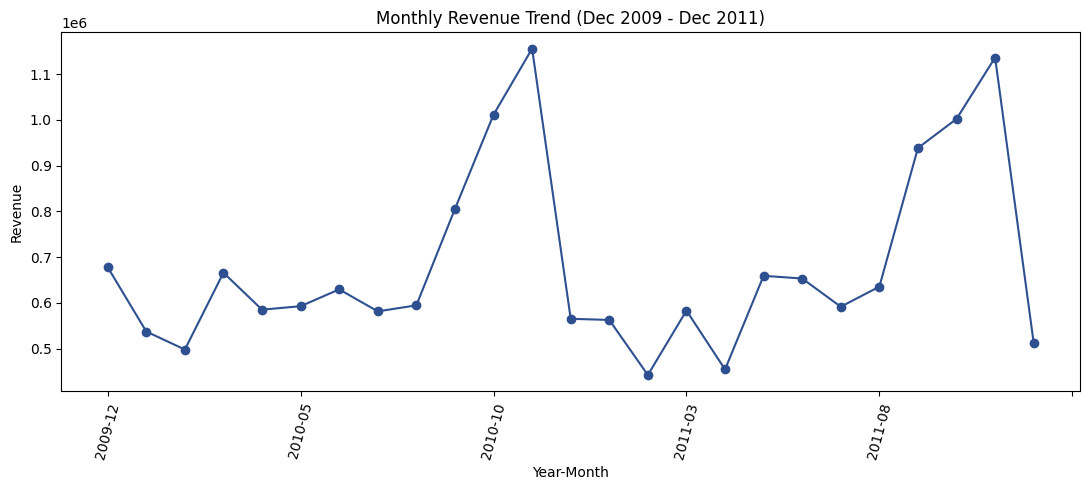

In [24]:
fig, ax = plt.subplots(figsize=(11,5))
monthly_revenue.plot(kind='line', marker='o', ax=ax, color='#2E5090')
ax.set_title('Monthly Revenue Trend (Dec 2009 - Dec 2011)')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/01_monthly_revenue_trend.png", dpi=120)
plt.show()

*Interpretation:* Revenue is highly seasonal, peaking around **October-November** each year
(pre-holiday buying), and dropping sharply in the December-January period after the seasonal peak.

**Chart 2 — Top 10 Products by Revenue**

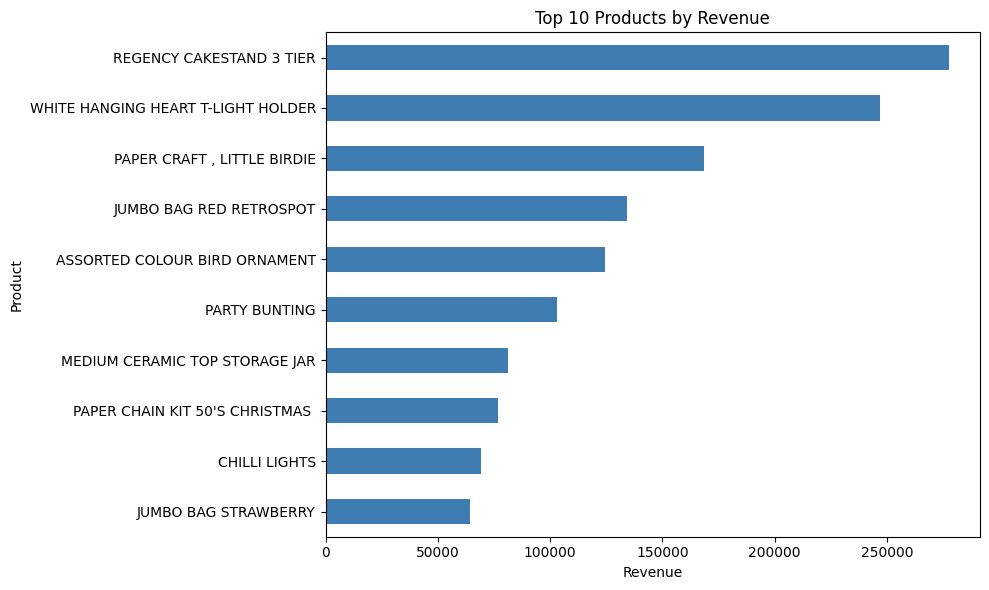

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
top_products_revenue.sort_values().plot(kind='barh', ax=ax, color='#3E7CB1')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/02_top10_products_revenue.png", dpi=120)
plt.show()

*Interpretation:* A small set of products dominates total revenue — these are prime candidates for stock priority and promotional focus.

**Chart 3 — Top 10 Countries by Revenue**

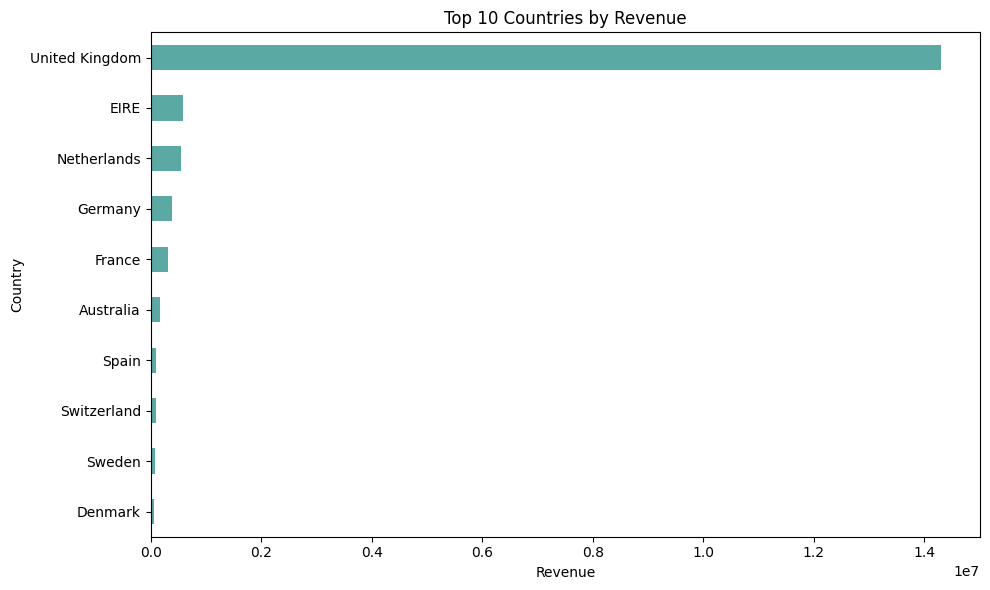

In [26]:
fig, ax = plt.subplots(figsize=(10,6))
top_countries_revenue.sort_values().plot(kind='barh', ax=ax, color='#5AA9A3')
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Revenue')
ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/03_top10_countries_revenue.png", dpi=120)
plt.show()

*Interpretation:* The business is heavily UK-concentrated. International revenue is real but secondary, which matters for shipping/marketing prioritisation.

**Chart 4 — Order Value Distribution**

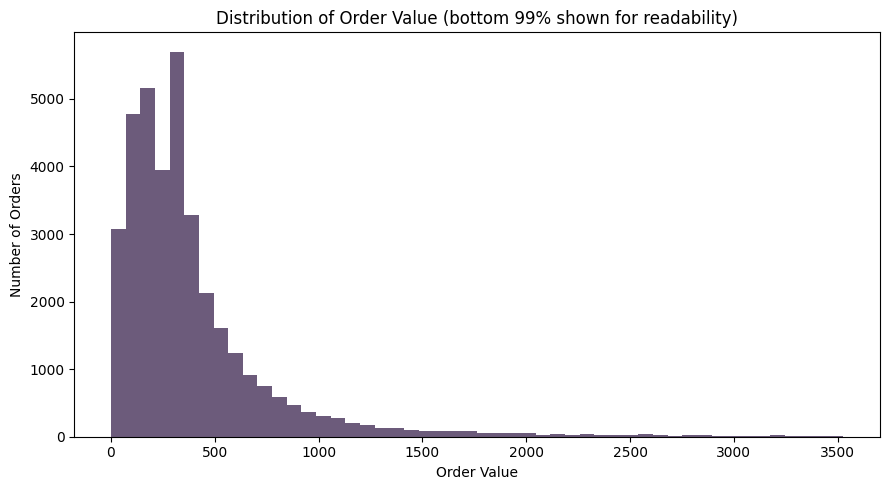

In [27]:
fig, ax = plt.subplots(figsize=(9,5))
order_values[order_values < order_values.quantile(0.99)].plot(kind='hist', bins=50, ax=ax, color='#6C5B7B')
ax.set_title('Distribution of Order Value (bottom 99% shown for readability)')
ax.set_xlabel('Order Value')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/04_order_value_distribution.png", dpi=120)
plt.show()

*Interpretation:* Order values are strongly right-skewed — most orders are modest, with a long tail of large orders that disproportionately drive revenue.

**Chart 5 — Customer Total-Spend Distribution**

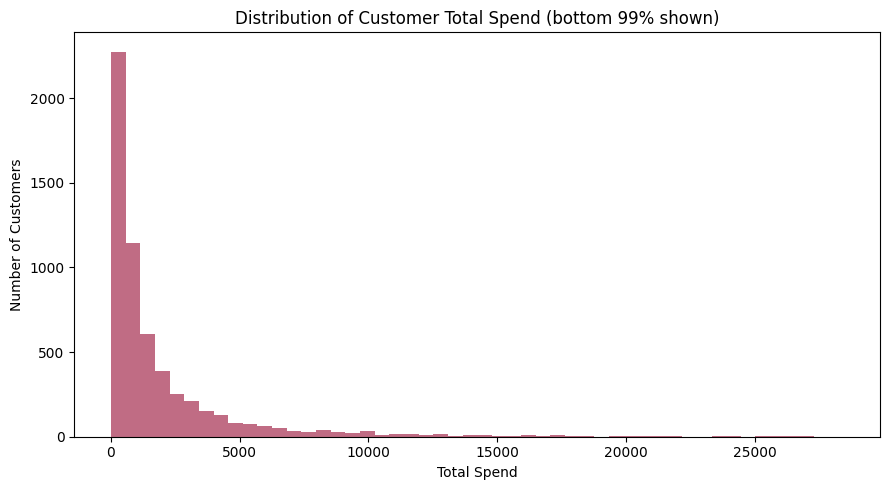

In [28]:
fig, ax = plt.subplots(figsize=(9,5))
spend_clipped = customer_features['TotalSpend'][customer_features['TotalSpend'] < customer_features['TotalSpend'].quantile(0.99)]
spend_clipped.plot(kind='hist', bins=50, ax=ax, color='#C06C84')
ax.set_title('Distribution of Customer Total Spend (bottom 99% shown)')
ax.set_xlabel('Total Spend')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/05_customer_spend_distribution.png", dpi=120)
plt.show()

*Interpretation:* Customer spend follows the classic retail pattern — a large base of low-to-moderate spenders and a smaller high-value tail, which justifies a percentile-based high-value definition rather than a fixed dollar cutoff.

**Chart 6 — Quantity per Order-Line Distribution (Boxplot)**

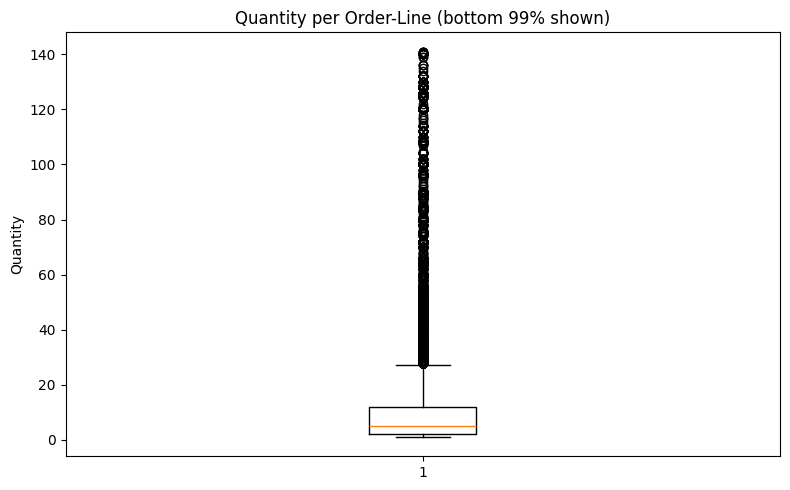

In [29]:
fig, ax = plt.subplots(figsize=(8,5))
qty_clipped = df_sales['Quantity'][df_sales['Quantity'] < df_sales['Quantity'].quantile(0.99)]
ax.boxplot(qty_clipped, vert=True)
ax.set_title('Quantity per Order-Line (bottom 99% shown)')
ax.set_ylabel('Quantity')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/06_quantity_boxplot.png", dpi=120)
plt.show()

*Interpretation:* Most order-lines involve small quantities (a handful of units), with a number of clear high-quantity outliers consistent with wholesale-style bulk buyers.

**Chart 7 — Revenue vs Quantity (Scatter)**

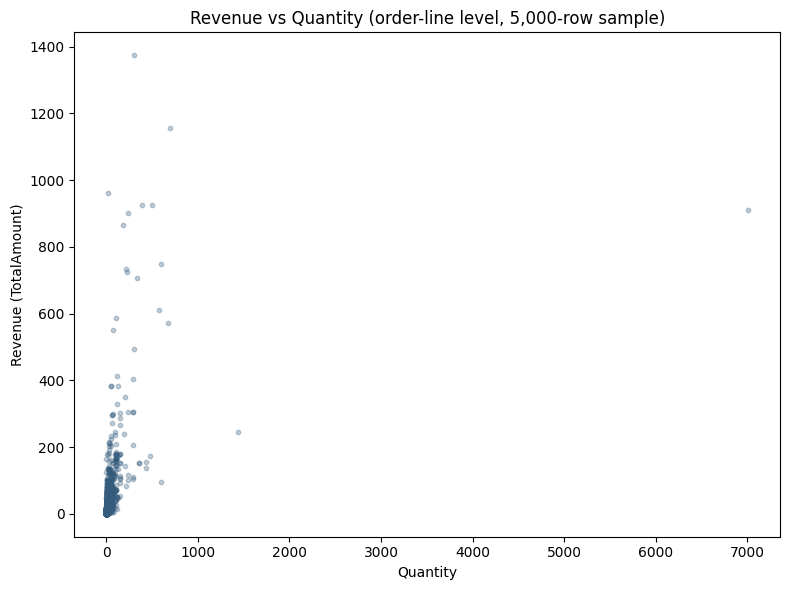

In [30]:
sample = df_sales.sample(n=min(5000, len(df_sales)), random_state=42)
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(sample['Quantity'], sample['TotalAmount'], alpha=0.3, s=10, color='#355C7D')
ax.set_title('Revenue vs Quantity (order-line level, 5,000-row sample)')
ax.set_xlabel('Quantity')
ax.set_ylabel('Revenue (TotalAmount)')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/07_revenue_vs_quantity_scatter.png", dpi=120)
plt.show()

*Interpretation:* Revenue generally rises with quantity, as expected, but price-per-unit differences mean the relationship is not perfectly linear — a few low-quantity, high-price items also generate strong revenue.

**Chart 8 — Monthly Order Count**

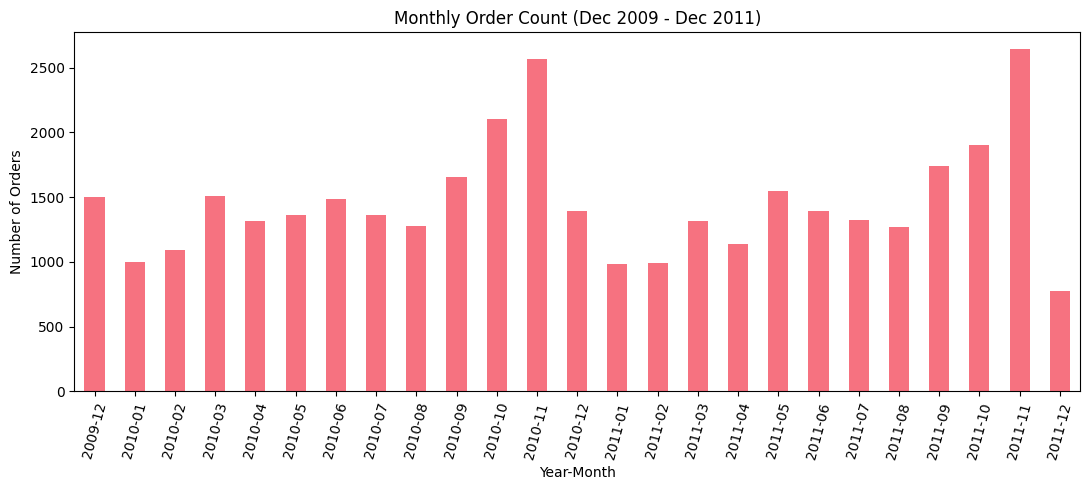

In [31]:
monthly_orders = df_sales.groupby('YearMonth')['Invoice'].nunique().sort_index()
fig, ax = plt.subplots(figsize=(11,5))
monthly_orders.plot(kind='bar', ax=ax, color='#F67280')
ax.set_title('Monthly Order Count (Dec 2009 - Dec 2011)')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/08_monthly_order_count.png", dpi=120)
plt.show()

*Interpretation:* Order counts follow the same seasonal pattern as revenue, confirming the November peak is driven by more orders, not just larger ones.

**Chart 9 — Sales by Day of Week**

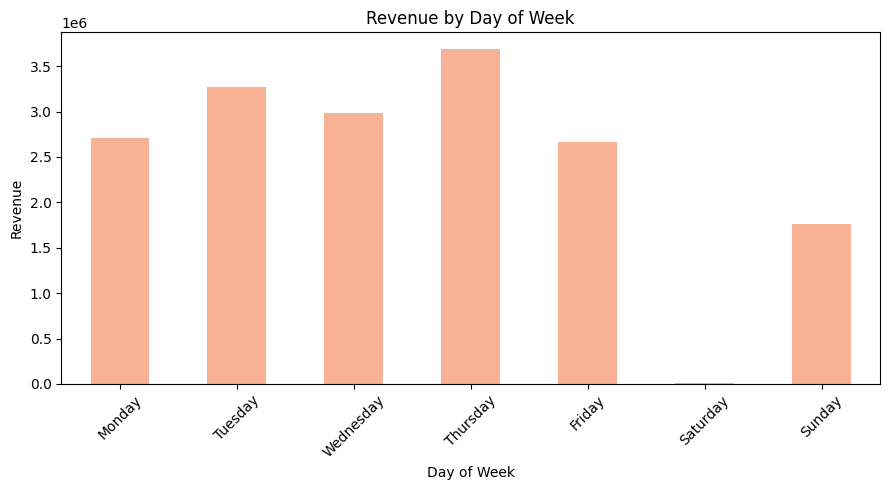

In [32]:
fig, ax = plt.subplots(figsize=(9,5))
revenue_by_dow.plot(kind='bar', ax=ax, color='#F8B195')
ax.set_title('Revenue by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/09_revenue_by_day_of_week.png", dpi=120)
plt.show()

*Interpretation:* Sales are concentrated on weekdays, with a visible drop on Saturday — useful for staffing and campaign-timing decisions.

**Chart 10 — Sales by Hour of Day**

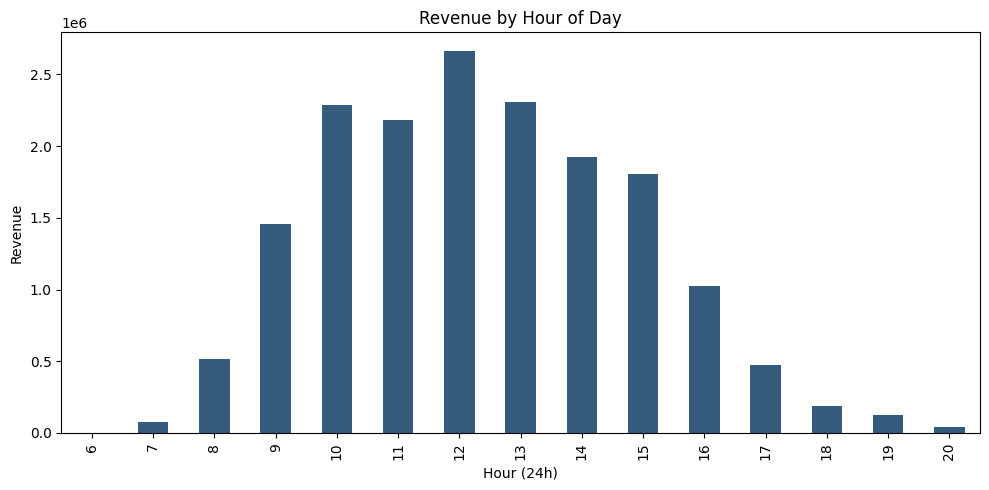

In [33]:
fig, ax = plt.subplots(figsize=(10,5))
revenue_by_hour.plot(kind='bar', ax=ax, color='#355C7D')
ax.set_title('Revenue by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/10_revenue_by_hour.png", dpi=120)
plt.show()

*Interpretation:* Revenue is concentrated in standard daytime business hours, peaking around late morning to early afternoon.

**Chart 11 — Top 10 Customers by Spending**

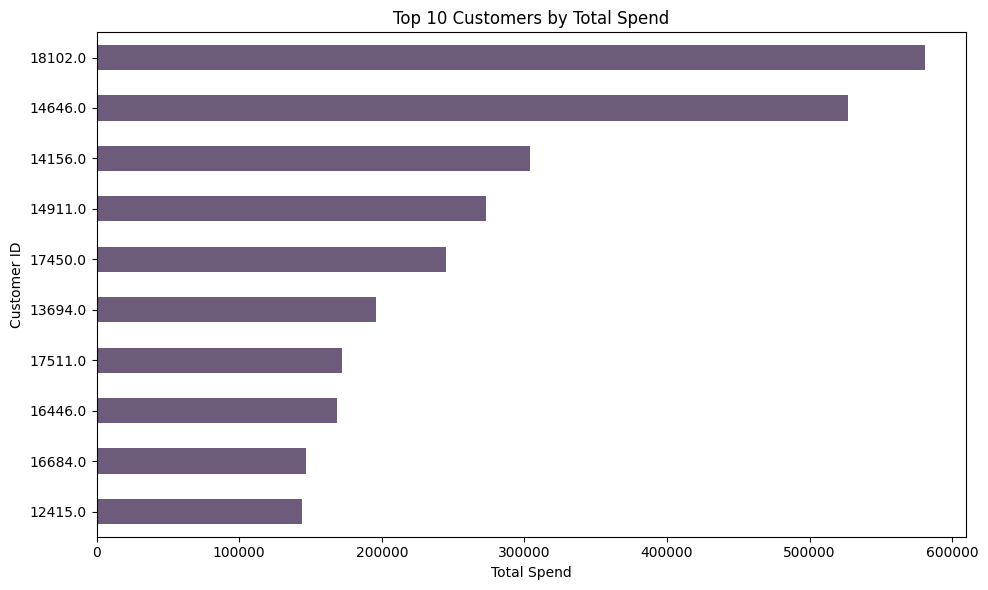

In [34]:
fig, ax = plt.subplots(figsize=(10,6))
top10_customers = customer_features.sort_values('TotalSpend', ascending=False).head(10).set_index('Customer ID')['TotalSpend']
top10_customers.sort_values().plot(kind='barh', ax=ax, color='#6C5B7B')
ax.set_title('Top 10 Customers by Total Spend')
ax.set_xlabel('Total Spend')
ax.set_ylabel('Customer ID')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/11_top10_customers.png", dpi=120)
plt.show()

*Interpretation:* A handful of customers contribute very large individual totals — these are strong candidates for dedicated account management or loyalty treatment.

**Chart 12 — Share of High-Value vs Other Customers (75th-percentile rule, full-period view)**

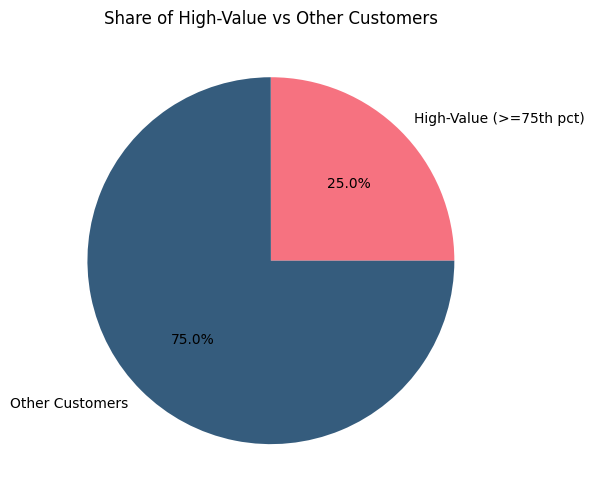

In [35]:
labels = ['High-Value (>=75th pct)', 'Other Customers']
sizes = [pct_above, 1 - pct_above]
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#F67280','#355C7D'])
ax.set_title('Share of High-Value vs Other Customers')
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/12_highvalue_share_pie.png", dpi=120)
plt.show()

*Interpretation:* Roughly a quarter of customers meet the high-value bar by construction (75th percentile). This confirms the rule produces a usable, moderately imbalanced classification target for Notebook 3.

## 10. Save the Cleaned Datasets

In [36]:
cleaned_full_path = f"{CLEAN_DIR}/online_retail_cleaned_flagged.csv"
cleaned_sales_path = f"{CLEAN_DIR}/online_retail_valid_sales.csv"
customer_features_path = f"{CLEAN_DIR}/customer_features_full_period.csv"

df_clean.to_csv(cleaned_full_path, index=False)
df_sales.to_csv(cleaned_sales_path, index=False)
customer_features.to_csv(customer_features_path, index=False)

print("Saved:")
print(" -", cleaned_full_path, "->", df_clean.shape)
print(" -", cleaned_sales_path, "->", df_sales.shape)
print(" -", customer_features_path, "->", customer_features.shape)
print("\nRaw source file at ../data/raw/online_retail_II.xlsx remains untouched.")

Saved:
 - ../data/cleaned/online_retail_cleaned_flagged.csv -> (1033036, 14)
 - ../data/cleaned/online_retail_valid_sales.csv -> (776624, 22)
 - ../data/cleaned/customer_features_full_period.csv -> (5861, 11)

Raw source file at ../data/raw/online_retail_II.xlsx remains untouched.


## 11. Summary of This Notebook

- Merged the two raw sheets into a single dataset after verifying identical schema
- Applied 8 documented, non-destructive cleaning rules (flag-based, not blind deletion)
- Built a valid completed-sales subset used for all revenue and customer analysis
- Created `TotalAmount`, date-part features, and a full customer-level feature table
- Answered 12 business questions and produced 12 interpreted Matplotlib charts
- Saved three cleaned outputs to `data/cleaned/`, keeping the raw file untouched

**Next step (Notebook 3):** build the leakage-safe historical/target time-split, define the high-value
label, train Logistic Regression and Random Forest, and evaluate against a baseline.
